In [3]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv("mtcars.csv")

In [7]:
print(df)

                  model   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  \
0             Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1   
1         Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1   
2            Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1   
3        Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0   
4     Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0   
5               Valiant  18.1    6  225.0  105  2.76  3.460  20.22   1   0   
6            Duster 360  14.3    8  360.0  245  3.21  3.570  15.84   0   0   
7             Merc 240D  24.4    4  146.7   62  3.69  3.190  20.00   1   0   
8              Merc 230  22.8    4  140.8   95  3.92  3.150  22.90   1   0   
9              Merc 280  19.2    6  167.6  123  3.92  3.440  18.30   1   0   
10            Merc 280C  17.8    6  167.6  123  3.92  3.440  18.90   1   0   
11           Merc 450SE  16.4    8  275.8  180  3.07  4.070  17.

Model Coefficients: Intercept = 6.2985, Slope = -0.5896
Predicted mpg for weight 5.5 is: 3.0556
Test Set RMSE: 0.3573
Test Set R² Score: 0.7426


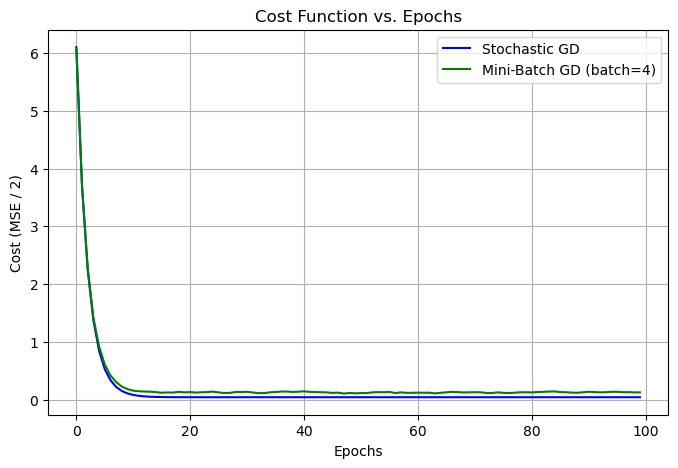

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load mtcars dataset
# Note: Ensure mtcars.csv is in your working directory or load via URL
url_mtcars = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df_mtcars = pd.read_csv(url_mtcars)

# Features and target: predicting 'mpg' using weight ('wt')
X = df_mtcars[['wt']].values
y = df_mtcars['mpg'].values

# Split dataset into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1. Custom Function for Simple Linear Regression (Closed-Form / OLS) ---
def myFnLinReg(x, y):
    """
    Computes slope (beta_1) and intercept (beta_0) using standard formulas:
    beta_1 = Cov(x, y) / Var(x)
    beta_0 = mean(y) - beta_1 * mean(x)
    """
    x = x.flatten()
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    beta_0 = y_mean - beta_1 * x_mean
    
    return beta_0, beta_1

# --- 2. Train Model ---
intercept, slope = myFnLinReg(X_train, y_train)
print(f"Model Coefficients: Intercept = {intercept:.4f}, Slope = {slope:.4f}")

# --- 3. Predict mpg for a car with weight = 5.5 ---
weight_input = 5.5
predicted_mpg = intercept + slope * weight_input
print(f"Predicted mpg for weight {weight_input} is: {predicted_mpg:.4f}")

# --- 4. Evaluate Test Set Performance ---
y_pred_test = intercept + slope * X_test.flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print(f"Test Set RMSE: {rmse:.4f}")
print(f"Test Set R² Score: {r2:.4f}")

# --- 5. Stochastic Gradient Descent (SGD) and Mini-Batch Gradient Descent ---

def compute_cost(X, y, w, b):
    m = len(y)
    predictions = X * w + b
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

# Standardize feature for stable gradient descent
x_mean_tr, x_std_tr = X_train.mean(), X_train.std()
X_train_scaled = (X_train - x_mean_tr) / x_std_tr

# SGD Implementation
def stochastic_gradient_descent(X, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        # Shuffle indices each epoch
        indices = np.random.permutation(m)
        for i in indices:
            xi = X[i]
            yi = y[i]
            prediction = xi * w + b
            error = prediction - yi
            
            # Gradients
            w_grad = error * xi
            b_grad = error
            
            w -= lr * w_grad
            b -= lr * b_grad
            
        cost_history.append(compute_cost(X.flatten(), y, w, b))
    return w, b, cost_history

# Mini-Batch GD Implementation
def mini_batch_gradient_descent(X, y, batch_size=4, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            predictions = X_batch * w + b
            errors = predictions - y_batch
            
            w_grad = (1 / len(y_batch)) * np.sum(errors * X_batch)
            b_grad = (1 / len(y_batch)) * np.sum(errors)
            
            w -= lr * w_grad
            b -= lr * b_grad
            
        cost_history.append(compute_cost(X.flatten(), y, w, b))
    return w, b, cost_history

# Run Optimizers
_, _, sgd_cost = stochastic_gradient_descent(X_train_scaled, y_train, lr=0.01, epochs=100)
_, _, mb_cost = mini_batch_gradient_descent(X_train_scaled, y_train, batch_size=4, lr=0.01, epochs=100)

# Visualize Cost Convergence
plt.figure(figsize=(8, 5))
plt.plot(sgd_cost, label='Stochastic GD', color='blue')
plt.plot(mb_cost, label='Mini-Batch GD (batch=4)', color='green')
plt.title('Cost Function vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE / 2)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load Boston Housing dataset
url_boston = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df_boston = pd.read_csv(url_boston)

# --- 1. Determine Top 5 Features to Predict 'medv' (using absolute Pearson correlation) ---
correlations = df_boston.corr()['medv'].drop('medv').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
top_3_features = correlations.head(3).index.tolist()

print("Top 5 correlated features with 'medv':", top_5_features)
print("Top 3 correlated features with 'medv':", top_3_features)

# --- 2. Multiple Linear Regression using Top 3 Features ---
X = df_boston[top_3_features]
y = df_boston['medv']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Display fitted parameters
print("\nModel Coefficients:")
for feat, coef in zip(top_3_features, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

# --- 3. Model Accuracy Metrics on Test Set ---
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Test Set Evaluation ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Top 5 correlated features with 'medv': ['lstat', 'rm', 'ptratio', 'indus', 'tax']
Top 3 correlated features with 'medv': ['lstat', 'rm', 'ptratio']

Model Coefficients:
  lstat: -0.5671
  rm: 4.9331
  ptratio: -0.8671
  Intercept: 14.5881

--- Test Set Evaluation ---
RMSE: 5.2072
MAE:  3.3325
R²:   0.6303
